In [2]:
!pip install transformers datasets[audio] accelerate

In [4]:
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests

In [5]:
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)


In [6]:
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-large')
model = AutoModel.from_pretrained('facebook/dinov2-large')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/549 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

In [7]:
inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
last_hidden_states = outputs.last_hidden_state

In [12]:
print(last_hidden_states.shape)

torch.Size([1, 257, 1024])


In [11]:
print(outputs.keys)

odict_keys(['last_hidden_state', 'pooler_output'])


In [14]:
import requests

import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

model_id = "IDEA-Research/grounding-dino-base"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(image_url, stream=True).raw)
# Check for cats and remote controls
# VERY important: text queries need to be lowercased + end with a dot
text = "a cat. a remote control."

inputs = processor(images=image, text=text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

In [16]:
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    text_threshold=0.3,
    target_sizes=[image.size[::-1]]
)

In [17]:
from pprint import pprint

In [19]:
pprint(results)

[{'boxes': tensor([[347.2289,  22.2235, 635.7134, 374.9651],
        [  9.8822,  51.2635, 318.5340, 472.6911],
        [ 37.9628,  71.1639, 176.5291, 117.9291],
        [332.6509,  73.3516, 371.5215, 189.2884]]),
  'labels': ['a cat', 'a cat', 'a remote control', 'a remote control'],
  'scores': tensor([0.4442, 0.4772, 0.4732, 0.3295]),
  'text_labels': ['a cat', 'a cat', 'a remote control', 'a remote control']}]


In [22]:
image_url = "https://imgs.search.brave.com/xQ7d1FNlVptrf370AE3RgDX97vpx_J_Jz3dgkZYnK9o/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9tZWRp/YS5nZXR0eWltYWdl/cy5jb20vaWQvMjE3/Nzk1Mzg0NS9waG90/by9zbWFsbC1vZmZp/Y2Utd29ya3BsYWNl/LWF0LWJyaWdodC1h/cGFydG1lbnQuanBn/P3M9NjEyeDYxMiZ3/PTAmaz0yMCZjPXFK/S0txV21fUTVIbFNR/WkJHRl83aUVJQ2pW/aV9reHE5NjFxUTVU/RDNNczA9"

In [23]:
image = Image.open(requests.get(image_url, stream=True).raw)
# Check for cats and remote controls
# VERY important: text queries need to be lowercased + end with a dot
text = "a monitor. a desk"

inputs = processor(images=image, text=text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

In [24]:
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    text_threshold=0.3,
    target_sizes=[image.size[::-1]]
)

In [25]:
pprint(results)

[{'boxes': tensor([[ 43.2095, 145.5168, 188.3127, 298.5052],
        [ 43.4117, 146.4155, 188.9603, 253.3900]]),
  'labels': ['a monitor', 'a monitor'],
  'scores': tensor([0.5030, 0.3107]),
  'text_labels': ['a monitor', 'a monitor']}]


In [27]:
from transformers import Sam2Processor, Sam2Model

sam_id = "facebook/sam2-hiera-large"

sam_processor = Sam2Processor.from_pretrained(sam_id)
sam_model = Sam2Model.from_pretrained(sam_id).to(device)

processor_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/5.71k [00:00<?, ?B/s]

[transformers] You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


model.safetensors:   0%|          | 0.00/898M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/741 [00:00<?, ?it/s]

In [28]:
result = results[0]

boxes = result["boxes"]
labels = result["labels"]

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


In [29]:
print(boxes, labels)

tensor([[ 43.2095, 145.5168, 188.3127, 298.5052],
        [ 43.4117, 146.4155, 188.9603, 253.3900]]) ['a monitor', 'a monitor']


In [30]:
input_boxes = [[box.tolist() for box in boxes]]

In [31]:
inputs = sam_processor(
    images=image,
    input_boxes=input_boxes,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = sam_model(**inputs)

In [33]:
masks = sam_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
)

In [34]:
masks = masks[0]

In [35]:
print(len(masks))

2


In [36]:
mask = masks[0][0]

print(mask.shape)

torch.Size([333, 500])


In [37]:
objects = []

for label, score, box, mask in zip(
    result["labels"],
    result["scores"],
    result["boxes"],
    masks,
):
    objects.append({
        "label": label,
        "score": float(score),
        "box": box.tolist(),
        "mask": mask[0].numpy()
    })

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


In [39]:
print(type(masks))
print(len(masks))

print(type(masks[0]))
print(len(masks[0]))

print(masks[0][0].shape)

<class 'torch.Tensor'>
2
<class 'torch.Tensor'>
3
torch.Size([333, 500])


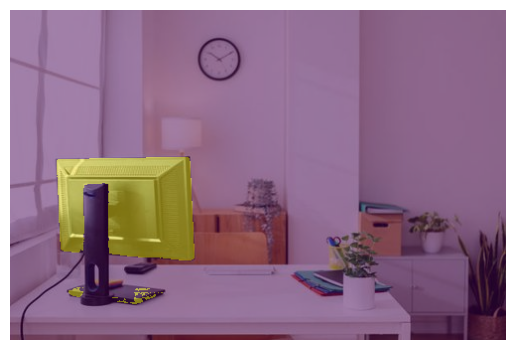

In [40]:
mask = masks[0][0].cpu().numpy()

plt.imshow(image)
plt.imshow(mask, alpha=0.5)
plt.axis("off")
plt.show()

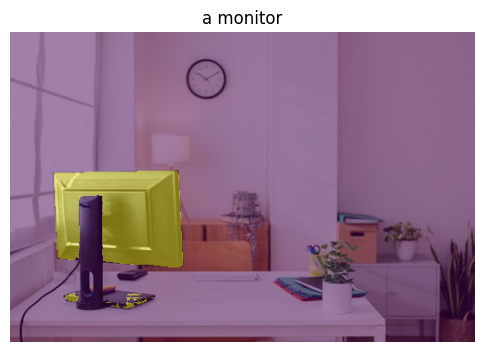

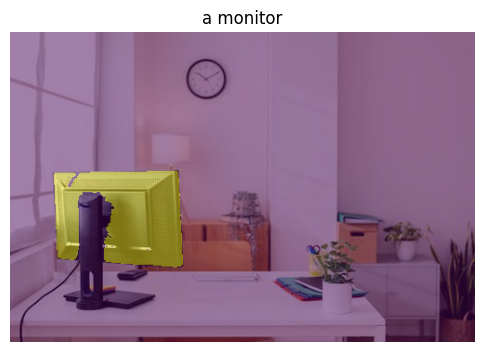

In [41]:
for i in range(len(masks)):
    mask = masks[i][0].cpu().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.imshow(mask, alpha=0.5)
    plt.title(result["labels"][i])
    plt.axis("off")